<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Logistic%20Regression%2C%20optimized%20with%20Stochastic%20Gradient%20Descent(SGD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install tensorflow tensorflow-datasets scikit-learn matplotlib seaborn numpy

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.NYMLTN_1.0.0/malaria-train.tfrecord-[0-9][0-9][0-9][0-9…

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.
Converting to NumPy arrays...
Training set shape: (22046, 3072)
Testing set shape:  (5512, 3072)

Training SGD Logistic Regression...
Epoch 5/30 | Loss: 2.5301
Epoch 10/30 | Loss: 2.4238
Epoch 15/30 | Loss: 2.3178
Epoch 20/30 | Loss: 2.3399
Epoch 25/30 | Loss: 2.2452
Epoch 30/30 | Loss: 2.2079

--- Model Evaluation Metrics ---
Accuracy : 0.6366
Precision: 0.6389
Recall   : 0.6284
F1 Score : 0.6336

                 precision    recall  f1-score   support

 Uninfected (0)       0.63      0.64      0.64      2756
Parasitized (1)       0.64      0.63      0.63      2756

       accuracy                           0.64      5512
      macro avg       0.64      0.64      0.64      5512
   weighted avg       0.64      0.64      0.64      5512



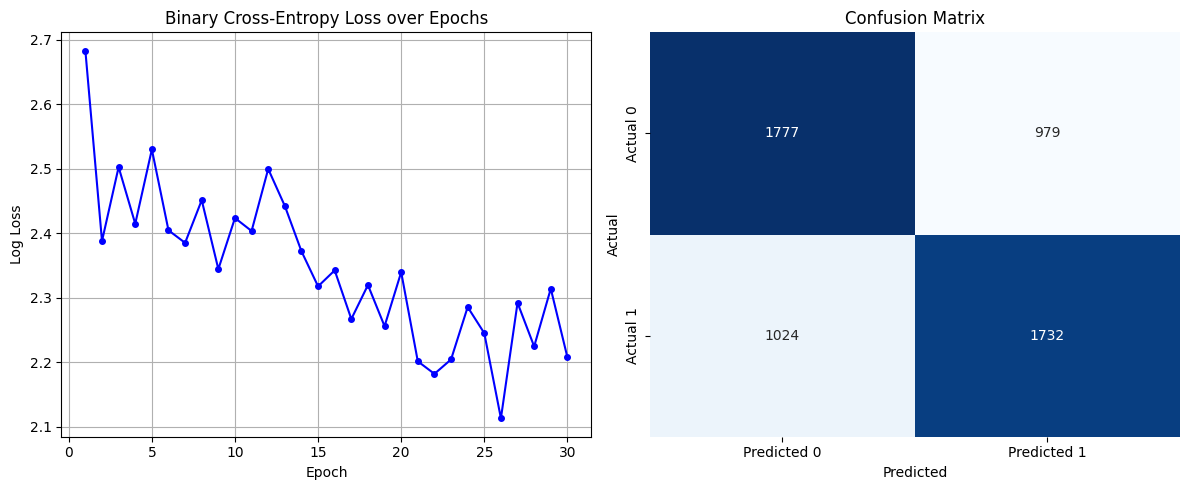

In [1]:
# Import Necessary Libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ==========================================================
# 1. DATA COLLECTION (TensorFlow Datasets)
# ==========================================================
print("Downloading and loading Malaria dataset from TFDS...")
# The TFDS malaria dataset has 27,558 images in a single 'train' split
ds, info = tfds.load('malaria', split='train', as_supervised=True, with_info=True)
total_examples = info.splits['train'].num_examples

# ==========================================================
# 2. DATA PREPROCESSING
# ==========================================================
IMG_SIZE = 32  # Resize to 32x32 to keep feature vector manageable (3072 features)

def preprocess(image, label):
    # Resize image
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Feature Scaling: Normalize pixels to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Flatten 3D image matrix into 1D feature vector
    image = tf.reshape(image, [-1])
    return image, label

# Map preprocessing pipeline efficiently
ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Train-Test Split (80% Train, 20% Test)
train_size = int(0.8 * total_examples)
train_ds = ds.take(train_size).batch(2048)
test_ds  = ds.skip(train_size).batch(2048)

# Convert TF datasets to NumPy arrays for the from-scratch SGD model
print("Converting to NumPy arrays...")
X_train_list, y_train_list = [], []
for x, y in train_ds.as_numpy_iterator():
    X_train_list.append(x); y_train_list.append(y)
X_train, y_train = np.vstack(X_train_list), np.concatenate(y_train_list)

X_test_list, y_test_list = [], []
for x, y in test_ds.as_numpy_iterator():
    X_test_list.append(x); y_test_list.append(y)
X_test, y_test = np.vstack(X_test_list), np.concatenate(y_test_list)

# Standard Scaling (Mean=0, Std=1) - Crucial for SGD convergence on pixel data
scaler_mean = X_train.mean(axis=0)
scaler_std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - scaler_mean) / scaler_std
X_test  = (X_test - scaler_mean) / scaler_std

print(f"Training set shape: {X_train.shape}") # Expected: (22046, 3072)
print(f"Testing set shape:  {X_test.shape}")  # Expected: (5512, 3072)

# ==========================================================
# 3. MODEL IMPLEMENTATION: SGD LOGISTIC REGRESSION (FROM SCRATCH)
# ==========================================================
class SGDLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=20, batch_size=128):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        self.m, self.n = X.shape
        self.weights = np.zeros(self.n)
        self.bias = 0.0

        for epoch in range(self.epochs):
            epoch_loss = 0
            indices = np.random.permutation(self.m)
            X_shuffled, y_shuffled = X[indices], y[indices]

            # Mini-batch SGD
            for i in range(0, self.m, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                batch_m = X_batch.shape[0]

                # Forward pass
                z = np.dot(X_batch, self.weights) + self.bias
                y_pred = self.sigmoid(z)

                # Binary Cross-Entropy Loss
                epsilon = 1e-15
                y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
                loss = -np.mean(y_batch * np.log(y_pred_clipped) + (1 - y_batch) * np.log(1 - y_pred_clipped))
                epoch_loss += loss * batch_m

                # Gradients
                error = y_pred - y_batch
                dw = (1 / batch_m) * np.dot(X_batch.T, error)
                db = (1 / batch_m) * np.sum(error)

                # Update parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            self.losses.append(epoch_loss / self.m)
            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{self.epochs} | Loss: {self.losses[-1]:.4f}")

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.weights) + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Initialize and Train
print("\nTraining SGD Logistic Regression...")
model = SGDLogisticRegression(learning_rate=0.1, epochs=30, batch_size=256)
model.fit(X_train, y_train)

# ==========================================================
# 4 & 5. EVALUATION AND VISUALIZATION
# ==========================================================
y_pred = model.predict(X_test)

print("\n--- Model Evaluation Metrics ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Uninfected (0)', 'Parasitized (1)']))

# Plotting
plt.figure(figsize=(12, 5))

# Plot 1: Log Loss Evolution
plt.subplot(1, 2, 1)
plt.plot(range(1, model.epochs + 1), model.losses, color='b', marker='o', linestyle='-', markersize=4)
plt.title('Binary Cross-Entropy Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.grid(True)

# Plot 2: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()